# **Esame del 10 settembre 2024**

- Non si possono consultare libri, note, ed ogni altro materiale o persone durante
l’esame ad eccezione delle funzioni Python fornite.

- Risolvere i seguenti esercizi con l’ausilio di Python.

- La durata del compito è di 90 minuti.

- Questo esame ha 3 domande, per un totale di 30/30 punti + 1 extra.

- Svolgere gli esercizi marcati con **[T]** su fogli protocollo, indicando: nome, cognome, codice persona
e data

# **Esercizio 1 (punti 10)**

Si consideri il seguente problema algebrico: data $A \in \mathbb{R}^{n\times n}$ e $b \in \mathbb{R}^n$ trovare $x\in \mathbb{R}^n$ tale che
$$
A x = b
$$
dove $A$ e $b$ sono dati da
$${A}=\left[\begin{array}{rrrrrrr}
9 & -3 & 1 &  &  & & \\
-3 & 9 & -3 & 1 &  & & \\
1 & -3 & 9 & -3 & 1 & & \\
& 1 & -3 & 9 & -3 & 1 &\\
& & 1 & -3 & 9 & -3 & 1 \\
& & & 1 & -3 & 9 & -3  \\
& & & & 1 & -3 & 9  \\
\end{array}\right]
\quad\quad {b}=\left[\begin{array}{c}7\\4\\5\\5\\5\\4\\7\end{array}\right].$$


#### **(1a) (2 punti) [T]**  

Uno schema iterativo per la soluzione di sistemi lineari si può scrivere nella seguente forma generale: dato $x^0 \in \mathbb{R}^n$ calcolo la soluzione tentativo al passo successivo $x^{k+1}\in \mathbb{R}^n$ come
$$
x^{k+1} = B x^{k} + g.
$$
Enunciare la condizione necessaria e sufficiente per la sua convergenza.

##### **Soluzione.**

Supponendo che il metodo sia consistente, ossia che data la soluzione esatta $x$ soddisfi $x=Bx+g$, la condizione necessaria e sufficiente per la convergenza è che il raggio spettrale della matrice di iterazione $B$ sia minore di uno,

$$\max |\lambda(B)|<1$$

Questo garantisce che a ogni iterazione l'errore si riduca.

#### **(1b) (3 punti) [T]**  

Illustrare i casi particolari del metodo di Jacobi e di Gauss-Seidel per la risoluzione del problema precedente, enunciarne quindi le condizioni di convergenza (sufficienti e necessarie-e-sufficienti).

##### **Soluzione.**

Entrambi i metodi si basano sul seguente splitting della matrice del sistema: $A=(A-P) + P$ dove $P$ è detta precondizionatore. Otteniamo che la generica iterazione si scrive come

$$P x^{k+1} = (P-A) x^k + b$$

e quindi la matrice di iterazione è $B=I-P^{-1}A$. Nel caso del metodo di Jacobi $P$ è una matrice diagonale con $p_{ii}=a_{ii}$ mentre nel caso del metodo di Gauss Seidel $P$ è la parte triangolare inferiore di $A$. La condizione necessaria e sufficiente è, per entrambi, quella enunciata al punto precendente, mentre le condizioni sufficienti sono:

Jacobi: matrice a dominanza diagonale stretta per righe o colonne;

Gauss-Seidel: matrice simmetrica definita positiva, oppure a dominanza diagonale stretta per righe o colonne.

#### **(1c) (2 punti) [P]**  

Verificare che per il problema in considerazione le condizioni sopra enunciate siano soddisfatte (verificare una condizione a scelta per metodo), utilizzando le funzioni `Jacobi_Bc` e `GS_Bc` per costruire le matrici di iterazione. Per il calcolo degli autovalori si può usare la funzione `eigvals` del pacchetto `scipy.linalg`.

##### **Soluzione.**



Un esempio di codice è il seguente.

In [4]:
import numpy as np
from scipy.linalg import eigvals

from functions import Jacobi_Bc, GS_Bc

# costruisci la matrice A
n = 7
A = -3 * np.diag(np.ones(n - 1), 1) + np.diag(np.ones(n - 2), 2)
A = 9 * np.diag(np.ones(n)) + A + A.T
print(A)
# matrice di iterazione per il metodo di Jacobi
B_j = Jacobi_Bc(A)

# calcola il raggio spettrale di B_j
rho_j = np.max(np.abs(eigvals(B_j)))
print(f"Raggio spettrale di B_j: {rho_j}")

# matrice di iterazione per il metodo di Gauss-Seidel
B_gs = GS_Bc(A)

# calcola il raggio spettrale di B_gs
rho_gs = np.max(np.abs(eigvals(B_gs)))
print(f"Raggio spettrale di B_gs: {rho_gs}")

[[ 9. -3.  1.  0.  0.  0.  0.]
 [-3.  9. -3.  1.  0.  0.  0.]
 [ 1. -3.  9. -3.  1.  0.  0.]
 [ 0.  1. -3.  9. -3.  1.  0.]
 [ 0.  0.  1. -3.  9. -3.  1.]
 [ 0.  0.  0.  1. -3.  9. -3.]
 [ 0.  0.  0.  0.  1. -3.  9.]]
Raggio spettrale di B_j: 0.7822534169452454
Raggio spettrale di B_gs: 0.2521947752539079


#### **(1d) (3 punti) [P]**

Sia $x^*\in \mathbb{R}^n$ soluzione di riferimento, calcolata come qui di seguito. Utilizzando la funzione `iterative_solve` risolvere il problema sia con il metodo di Jacobi che con il metodo di Gauss-Seidel. Calcolare l'errore relativo ottenuto rispetto a $x^*$ e il numero di iterazioni effettuate. Commentare i risultati ottenuti.

Si utilizzi una tolleranza relativa pari a $1e-6$ e un numero massimo di iterazioni pari a 100.

In [ ]:
from functions import iterative_solve

# b = ...

x_star = np.linalg.solve(A, b)

NameError: name 'b' is not defined

##### **Soluzione.**



Un esempio di codice è il seguente.

In [2]:
from functions import iterative_solve

# costruisci il vettore b
b = np.array([7, 4, 5, 5, 5, 4, 7])

x0 = np.zeros(n)

# calcola la soluzione di riferimento
x_star = np.linalg.solve(A, b)

# calcola la soluzione con il metodo di Jacobi
x_j = iterative_solve(A, b, x0, method="Jacobi", nmax=100, rtoll=1e-6)
err_j = np.linalg.norm(x_j[-1] - x_star) / np.linalg.norm(x_star)

# calcola la soluzione con il metodo di Gauss-Seidel
x_gs = iterative_solve(A, b, x0, method="GS", nmax=100, rtoll=1e-6)
err_gs = np.linalg.norm(x_gs[-1] - x_star) / np.linalg.norm(x_star)

# stampa gli errori e il numero di iterazioni
print(err_j, len(x_j))
print(err_gs, len(x_gs))

3.206429167036422e-07 50
2.1202790283184754e-07 13


Osserviamo che entrambi i metodi convergono, e, in particolare, come previsto dalla teoria, il metodo di Gauss-Seidel converge più velocemente.

# **Esercizio 2 (10 punti)**


Si consideri la seguente funzione $f$ definita nell'intervallo $I = [-\frac{3}{4}, \frac{3}{4}]$, estremi inclusi:

$$
f(x) = x \sin(2\pi x)^2
$$

#### **(2a) (1 punti) [P+T]**

Rappresentare graficamente la funzione $f$ e calcolare analiticamente i suoi zeri nell'intervallo $I$.

##### **Soluzione.**



La funzione si annulla in $0$, $\frac{1}{2}$ e $-\frac{1}{2}$, come confermato dal grafico che si ottiene con il seguente codice:

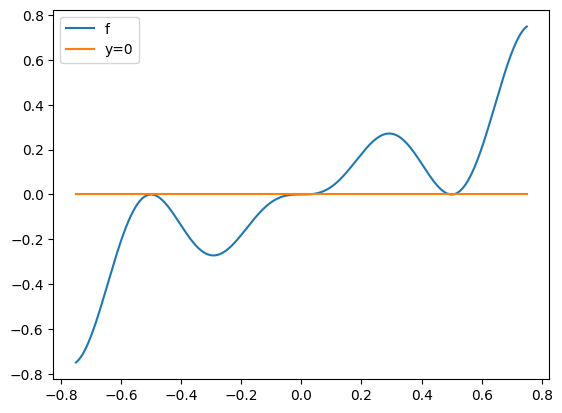

In [6]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda x: x * np.sin(2 * np.pi * x) ** 2
N = 1000
x = np.linspace(-0.75, 0.75, N)

plt.plot(x, f(x), label="f")
plt.plot(x, np.zeros_like(x), label="y=0")
plt.legend()

#### **(2b) (3 punti) [T]**

Derivare il metodo di Newton e Newton modificato per la ricerca degli zeri di una funzione, specificandone le proprietà di convergenza.

##### **Soluzione.**



 Dato, all'iterazione $k$, un valre di tentativo per lo zero esatto $x^k \in \mathbb{R}$, la retta tangente a $f$ in $x^k$ è data da

$$
\dfrac{f(x)-f(x^k)}{x-x^k} = f'(x^k) \quad \Rightarrow \quad f(x) = f(x^k) +f'(x^k)(x-x^k).
$$

Quindi dato $x^k$, il punto $x^{k+1}$ è trovato come punto di intersezione della retta tangente l'asse $x$ ovvero lo zero della retta tangente approssimante $f$. Abbiamo che

$$
f(x^{k+1}) = f(x^k) + f'(x^k)(x^{k+1}-x^k) = 0 \quad \Rightarrow \quad x^{k+1} = x^{k} - \dfrac{f(x^k)}{f'(x^k)}.
$$

Per la convergenza ci basiamo sul seguente risultato:

**Teorema 1.** Sia $f:[a,b]\rightarrow \mathbb{R}$ una funzione di classe $\mathcal{C}^2$ in $[a,b]$. Sia $\alpha$ tale che $f(\alpha) = 0$ e $f'(\alpha) \neq 0$, ovvero di molteplicità algebrica pari a 1. Allora esiste $\eta > 0$ tale che scelgo $x^0$ in modo che $|x^0-\alpha|<\eta$ allora si ha
$$
\forall k \in \mathbb{N} \quad |x^k-\alpha|<\eta,
$$
inoltre il metodo risulta convergente, ovvero
$$
\lim_{k\to\infty} x^k = \alpha,
$$
infine il meotodo di Newton ha una convergenza quadratica, abbiamo
$$
\lim_{k\to\infty} \dfrac{x^{k+1}-\alpha}{(x^k-\alpha)^2} = C = \dfrac{f''(\alpha)}{2f'(\alpha)}
$$

Introducendo $m$ come molteplicità algebrica dello zero $\alpha$, possiamo quindi presentare il metodo di Newton modificato come

$$
x^{k+1} = x^k - m \dfrac{f(x^k)}{f'(x^k)}.
$$

Se tale metodo converge, allora converge quadraticamente, come nel caso di Newton la convergenza è solo locale, cioè per un $x^0$ sufficientemente vicino al valore di $\alpha$.


#### **(2c) (4 punti) [P]**

Date le proprietà di convergenza sopra descritte, e le proprietà degli zeri, calcolare questi ultimi utilizzahndo la funzione `newton`. Si utilizzino i punti di partenza dati da $x_0 = \alpha + \epsilon$, dove $\alpha$ è lo zero esatto e $\epsilon = 0.1$.

**Attenzione** si utilizzino in maniera *opportuna* il metodo di Newton o di Newton modificato per ottenere la più rapida convergenza.

##### **Soluzione.**

Calcoliamo innanzitutto la molteplicità delle radici trovate. Calcoliamo le derivate:

$$f'(x) = 4\pi x \sin(2\pi x)\cos(2\pi x) + \sin(2\pi x)^2$$

$$f''(x) = 4\pi \sin(2\pi x)\cos(2\pi x) + 8\pi^2 x (\cos(2\pi x) - \sin(2\pi x))  + 4\pi\sin(2\pi x)\cos(2\pi x)$$

Notiamo che in $\alpha_1=-0.5$ e $\alpha_3 = 0.5$ si annulla la derivata prima, ma non la seconda, mentre in $\alpha_2=0$ si annullano entrambe. Abbiamo $m_1=m_3=2$, $m_2=3$.

In [ ]:
from functions import newton

f = lambda x: x * np.sin(2 * np.pi * x) ** 2
df = lambda x: np.sin(2 * np.pi * x) ** 2 + 4 * np.pi * x * np.sin(
    2 * np.pi * x
) * np.cos(2 * np.pi * x)

eps = 1e-1

# primo zero (m=2)
x0 = -0.5 + eps
x_star = newton(f, df, x0, m=2)
print(x_star[-1], x_star.size)

# secondo zero (m=3)
x0 = 0 + eps
x_star = newton(f, df, x0, m=3)
print(x_star[-1], x_star.size)

# terzo zero (m=2)
x0 = 0.5 + eps
x_star = newton(f, df, x0, m=2)
print(x_star[-1], x_star.size)

#### **(2d) (2 punti) [P+T]**

Identificare per quale zero di $f$ è possibile applicare il metodo di bisezione, quindi usare la funzione `bisez` per calcolarlo. Si commenti il risultato ottenuto.

##### **Soluzione.**



Solo per $\alpha=0$ possiamo applicare il metodo di bisezione dato che esiste un intorno tale per cui $f(a) f(b) < 0$, ad esempio per $a=-0.75$ e $b=0.75$.

In [9]:
from functions import bisez

a, b = -0.75, 0.75
x_star = bisez(f, a, b)
print(x_star[-1], x_star.size)

x è uno zero della funzione
0.0 1


La soluzione viene calcolata con un solo passo in quanto in questo caso lo zero è il punto medio di $a$ e $b$.

# **Esercizio 3 (10+1 punti)**




Si consideri il seguente problema differenziale tempo dipendente sul dominio $\Omega_T=(a,b)\times[0,T)$

$$
\begin{cases}
\partial_t u - \partial_{xx}u = f\quad \mathrm{in}\,\Omega_T\\
u(x,0) = 0 \quad \mathrm{in}\,(a,b)\\
u(a,t) = 0 \quad \mathrm{in}\,[0,T)\\
u(b,t) = 0 \quad \mathrm{in}\,[0,T),
\end{cases}
$$

con $a=0$, $b=1$, $f=1$ e $T=1$.

#### **(3a) (4 punti) [T]**

Introdurre per il problema in esame la discretizzazione in spazio con il metodo degli elementi finiti, e in tempo con il generico theta metodo.

##### **Soluzione.**


Consideriamo ora un problema tempo dipendente, l'equazione del calore. Nel caso
mono-dimensionale, dato $\Omega_T = \Omega  \times (0, 1)$ con $\Omega= (0, 1)$, risulta
\begin{gather*}
    \begin{cases}
        \partial_t u -  \partial_{xx} u = f & \text{in } \Omega_T            \\
        u(0, t) = 0                                 & \text{per } t \in [0, T)       \\
        u(1, t) = 0                                  & \text{per } t \in [0, T)       \\
        u(x, 0) = 0                                     & \text{in } \Omega \times \{0\}
    \end{cases}
\end{gather*}
La soluzione ora è una variabile che dipende sia dallo spazio che dal tempo
$u(x, t) : \Omega_T \rightarrow \mathbb{R}$. 
Consideriamo ora lo spazio funzionale $V=H^1_0(\Omega)$
e prendiamo delle funzioni test $v \in V$ che sono indipendenti da $t$; la forma
debole del problema definita dall'equazione del calore è data da: trovare, per
ogni $t \in (0, 1)$, $u(x, t) \in V$ tale che
\begin{gather*}
    \int_0^1 {\partial_t u} v dx
    +\int_0^1     \partial_x u
    \partial_x v dx = \int_0^1 f v dx \qquad
    \forall v \in V.
\end{gather*}
La formulazione discreta del problema è derivata fissando il tempo ed operando
prima in spazio. Scegliendo $V_h \subset V$ sotto-spazio finito
dimensionale otteniamo che la semi-discretizzazione in spazio è: trovare, per
ogni $t \in (0, 1)$, $u_h(t) \in V_h$ tale che
\begin{gather*}
    \int_0^1 \partial_t u_h v_h dx
    +\int_0^1  
    \partial_x u_h \partial_x v_h dx =
    \int_0^1 f v_h dx \qquad
    \forall v_h \in V_h.
\end{gather*}
Introduciamo ora le forme $a$ e $m$ e il funzionale $F$ definiti
come
\begin{gather*}
    a(u_h, v_h) = \int_0^1 \partial_x u_h
    \partial_x v_h
    \quad\text{e} \quad
    m(u_h, v_h) = \int_0^1 u_h v_h
    \quad\text{e} \quad
    F(v_h) = \int_0^1 f v_h dx
\end{gather*}
il precedente problema può quindi essere scritto come:
\begin{gather*}
    m(\partial_t u_h(t), v_h)
    + a(u_h, v_h) =
    F(v_h) \qquad
    \forall v_h \in V_h.
\end{gather*}
Anche in questo caso consideriamo una base $\{\phi_j\}$ per $V_h$ di funzioni
linearmente indipendenti,
consideriamo lo sviluppo di $v_h$ e $u_h$ sulla base $\{\phi_j \}$ di $V_h$
otteniamo
\begin{gather*}
    v_h(x) = \sum_{i=1}^{N_h} \alpha_i \phi_i (x)
    \quad \text{e} \quad
    u_h(x, t) = \sum_{j=1}^{N_h} u_j(t) \phi_j (x)
\end{gather*}

Sfruttando la bi-linearità della forma $a$, il fatto che il dominio non
dipende dal tempo e la linearità del funzionale $F$
otteniamo la seguente espressione
\begin{gather*}
    \partial_t m\left(\sum_{j=1}^{N_h} u_j(t) \phi_j, \phi_i\right)
    + a\left(\sum_{j=1}^{N_h} u_j(t) \phi_j, \phi_i\right) =
    F(\phi_i) \qquad
    \forall i=1,\ldots, N_h\\
    \sum_{j=1}^{N_h} \partial_t u_j(t)
    m\left(\phi_j, \phi_i\right)
    + \sum_{j=1}^{N_h} u_j(t) a\left(\phi_j, \phi_i\right) =
    F(\phi_i) \qquad
    \forall i=1,\ldots, N_h,
\end{gather*}
introduciamo la matrice di rigidezza $A$ e di massa $M$ date rispettivamente da
\begin{gather*}
    A \in \mathbb{R}^{N_h \times N_h}: \quad a_{ij} = a\left(\phi_j,
    \phi_i\right) \\
    M \in \mathbb{R}^{N_h \times N_h}: \quad m_{ij} = m\left( \phi_j,
    \phi_i \right)
\end{gather*}
Notiamo che la matrice di massa ha la stessa struttura della matrice introdotta per descrivere il termine di reazione in precedenza.
Il problema semi-discreto risulta quindi di determinare il vettore tempo
dipendente $\mathbf{u}(t)$ tale che
\begin{gather*}
    M d_t \mathbf{u}(t) + A \mathbf{u}(t) =
    \mathbf{f}.
\end{gather*}
Notiamo che abbiamo un sistema di equazioni differenziali ordinarie in tempo di
dimensione $N_h$, che può essere scritto formalmente nel seguente modo
\begin{gather*}
    \begin{cases}
        d_t \mathbf{u}(t) = \mathbf{\tilde{f}}(t, \mathbf{u}) \\
        \mathbf{u}(0) = \mathbf{u}_0
    \end{cases}
\end{gather*}
dove appunto $\mathbf{\tilde{f}}(t, \mathbf{u}) = - M^{-1} A \mathbf{u}(t) + M^{-1}\mathbf{f}$. La soluzione iniziale $\mathbf{u}_0$ dipende solamente
dallo spazio e può essere approssimata come
\begin{gather*}
    u_{0,h}(x) = \sum_{j=1}^{N_h} u_{0,j} \phi_j (x).
\end{gather*}
Introduciamo quindi ora una discretizzazione in tempo, ovvero
dividiamo l'intervallo $(0, 1]$ in $N_t$ sotto-intervalli temporali tale che
\begin{gather*}
    t_0 = 0 \qquad t_{N_t} = 1 \qquad t^n = n \Delta t,
\end{gather*}
dove $\Delta t$ è il passo di discretizzazione temporale definito come $\Delta
    t = 1/N_t$. Possiamo quindi utilizzare gli schemi di avanzamento temporale già
studiati, in particolare la derivata in tempo viene discretizzata come
\begin{gather*}
    d_t \mathbf{u} \approx \frac{\mathbf{u}(t^{n+1}) - \mathbf{u}(t^{n}) }{\Delta t} =
    \frac{\mathbf{u}^{n+1} - \mathbf{u}^{n} }{\Delta t}.
\end{gather*}
Il $\theta$-metodo può essere ora scritto come
\begin{gather*}
    M \frac{\mathbf{u}^{n+1} - \mathbf{u}^{n} }{\Delta t} + \theta A \mathbf{u}^{n+1} +
    (1-\theta) A \mathbf{u}^n = \theta \mathbf{f}^{n+1} + (1-\theta) \mathbf{f}^n
\end{gather*}
che è un sistema algebrico che dobbiamo risolvere ad ogni passo di
discretizzazione temporale. Ad ogni istante temporale dobbiamo risolvere un
problema del tipo
\begin{gather*}
    \left( \frac{M}{\Delta t} +  \theta A \right) \mathbf{u}^{n+1} = \left( \frac{M}{\Delta t}
    - (1-\theta) A \right)
    \mathbf{u}^n + \theta \mathbf{f}^{n+1} + (1-\theta) \mathbf{f}^n.
\end{gather*}

#### **(3b) (2 punti) [P]**

Completare la funzione `heatsolve` fornita assemblando, all'interno del ciclo temporale, la matrice ed il termine noto per un generico theta.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from fem import install
from fem import xtplot

install()

In [2]:
from fem import Line, generate_mesh, FEspace, assemble, interpolate, deriv, dx, ds, DirichletBC, applyBCs, dof2fun, fun2dof, dofs, plot

def heatSolve(D,f,u0,L,h,T,dt,theta):
  """"
  Input:
     D      (float)                  Coefficiente di diffusione (positivo).
     f      (lambda function)        Forzante. Si assume f = f(x,t).
     u0     (lambda function)        Condizione iniziale.
     L      (float)                  Lunghezza dell'intervallo spaziale.
     h      (float)                  Passo della griglia spaziale.
     T      (float)                  Tempo finale
     dt     (float)                  Passo temporale.
     theta  (float)                  Parametro del theta-metodo.

  Output:
    V                               spazio elementi finiti
    u     (numpy.ndarray)-> matrix  Matrice contenente la soluzione
                                    approssimata del problema. Uij
                                    approssima u(dof_i, tj): ogni colonna è un
                                    tempo fissato.
    t      (numpy.ndarray)-> vector Griglia temporale.
  """""
  # costruisco il dominio
  domain = Line(0, L)
  # costruisco la mesh
  mesh = generate_mesh(domain, stepsize = h)
  # costruisco lo spazio FEM di grado 1
  V = FEspace(mesh, 1)

  # costruisco la griglia temporale
  nt = np.ceil(T/dt)+1
  t = np.zeros(int(nt))

  # initializzo la soluzione
  u = np.zeros((dofs(V).size, int(nt)))

  # definisco la condizione iniziale
  u0h = fun2dof(interpolate(u0,V))
  u[:, 0] = u0h

  # matrice di massa
  def m(u, v):
    return u*v*dx
  # assemblaggio matrice di massa
  M = assemble(m, V)

  # matrice di diffusione
  def a(u,v):
    return deriv(u)*deriv(v)*dx
  # assemblaggio matrice di diffusione
  A = D*assemble(a,V)

  # ciclo temporale
  for n in range(int(nt)-1):
    # costruzioni termini noti al tempo dt e dt+1
    t_old = n*dt
    t_new = (n+1)*dt

    fold = lambda x: f(x,t_old)
    fnew = lambda x: f(x,t_new)

    fold_h = interpolate(fold, V)
    def lold(v):
      return fold_h*v*dx
    Fold = assemble(lold, V)

    fnew_h = interpolate(fnew, V)
    def lnew(v):
      return fnew_h*v*dx
    Fnew = assemble(lnew, V)

    # condizioni al bordo omogenee di tipo dirichlet
    def isLeftNode(x):
      return x < 1e-12

    def isRightNode(x):
      return x > L - 1e-12

    dbc1 = DirichletBC(isLeftNode,  0.0)
    dbc2 = DirichletBC(isRightNode, 0.0)

    A = applyBCs(A, V, dbc1, dbc2)
    M = applyBCs(M, V, dbc1, dbc2)
    Fold = applyBCs(Fold, V, dbc1, dbc2)
    Fnew = applyBCs(Fnew, V, dbc1, dbc2)

    # TODO: assemblare la matrice e il termine noto per il theta metodo
    B =
    b =

    from scipy.sparse.linalg import spsolve

    u[:,n+1] = spsolve(B, b)
    t[n+1] = t_new

  return V,u,t


#### **Soluzione**


Un esempio di soluzione è riportata nel codice seguente.

In [ ]:
def heatSolve(D, f, u0, L, h, T, dt, theta):
    """"
  Input:
     D      (float)                  Coefficiente di diffusione (positivo).
     f      (lambda function)        Forzante. Si assume f = f(x,t).
     u0     (lambda function)        Condizione iniziale.
     L      (float)                  Lunghezza dell'intervallo spaziale.
     h      (float)                  Passo della griglia spaziale.
     T      (float)                  Tempo finale
     dt     (float)                  Passo temporale.
     theta  (float)                  Parametro del theta-metodo.

  Output:
    V                               spazio elementi finiti
    u     (numpy.ndarray)-> matrix  Matrice contenente la soluzione
                                    approssimata del problema. Uij
                                    approssima u(dof_i, tj): ogni colonna è un
                                    tempo fissato.
    t      (numpy.ndarray)-> vector Griglia temporale.
  """ ""
    # costruisco il dominio
    domain = Line(0, L)
    # costruisco la mesh
    mesh = generate_mesh(domain, stepsize=h)
    # costruisco lo spazio FEM di grado 1
    V = FEspace(mesh, 1)

    # costruisco la griglia temporale
    nt = np.ceil(T / dt) + 1
    t = np.zeros(int(nt))

    # initializzo la soluzione
    u = np.zeros((dofs(V).size, int(nt)))

    # definisco la condizione iniziale
    u0h = fun2dof(interpolate(u0, V))
    u[:, 0] = u0h

    # matrice di massa
    def m(u, v):
        return u * v * dx

    # assemblaggio matrice di massa
    M = assemble(m, V)

    # matrice di diffusione
    def a(u, v):
        return deriv(u) * deriv(v) * dx

    # assemblaggio matrice di diffusione
    A = D * assemble(a, V)

    # ciclo temporale
    for n in range(int(nt) - 1):
        # costruzioni termini noti al tempo dt e dt+1
        t_old = n * dt
        t_new = (n + 1) * dt

        fold = lambda x: f(x, t_old)
        fnew = lambda x: f(x, t_new)

        fold_h = interpolate(fold, V)

        def lold(v):
            return fold_h * v * dx

        Fold = assemble(lold, V)

        fnew_h = interpolate(fnew, V)

        def lnew(v):
            return fnew_h * v * dx

        Fnew = assemble(lnew, V)

        # condizioni al bordo omogenee di tipo dirichlet
        def isLeftNode(x):
            return x < 1e-12

        def isRightNode(x):
            return x > L - 1e-12

        dbc1 = DirichletBC(isLeftNode, 0.0)
        dbc2 = DirichletBC(isRightNode, 0.0)

        A = applyBCs(A, V, dbc1, dbc2)
        M = applyBCs(M, V, dbc1, dbc2)
        Fold = applyBCs(Fold, V, dbc1, dbc2)
        Fnew = applyBCs(Fnew, V, dbc1, dbc2)

        # Costruzione del sistema lineare e sua risoluzione
        B = M / dt + theta * A
        b = (M / dt - (1 - theta) * A) @ u[:, n] + theta * Fnew + (1 - theta) * Fold

        from scipy.sparse.linalg import spsolve

        u[:, n + 1] = spsolve(B, b)
        t[n + 1] = t_new

    return V, u, t

#### **(3c) (2 punti) [P+T]**

Risolvere il problema con il metodo di Eulero Implicito, ponendo $h=0.1$ e $dt = 0.01$. Rappresentare e commentare il risultato ottenuto.

##### **Soluzione.**

Un esempio di soluzione è dato dal seguente codice.

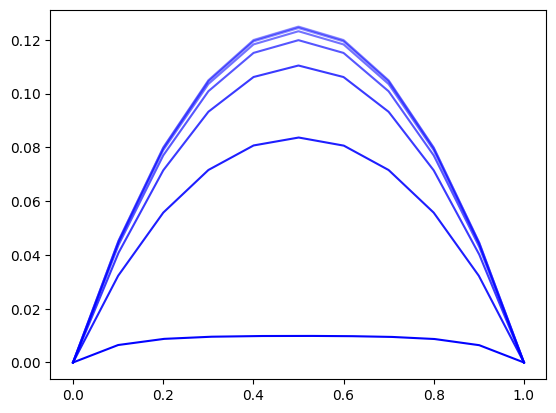

In [14]:
# Dati del problema del calore
T = 1
dt = 0.01
# intervallo
L = 1
h = 0.1
# coefficiente di diffusione
D = 1
# parametro per il theta methodo
theta = 1
# termine noto
f = lambda x, t: 1
# condizione iniziale
u0 = lambda x: 0

# risoluzione equazione del calore
V, u, t = heatSolve(D, f, u0, L, h, T, dt, theta)

# soluzione approssimata
xtplot(V, u, t, "fade")
plt.show()

Si osserva che la soluzione cresce fino a raggiungere uno stato stazionario.

#### **(3d) (1 punto) [P]**

Rappresentare l'andamento della soluzione in $x=0.5$ al variare del tempo.

#### **Soluzione**

Un esempio di soluzione è data dal seguente codice.

[0.         0.00099996 0.00200018 ... 0.11999373 0.11999379 0.11999386]


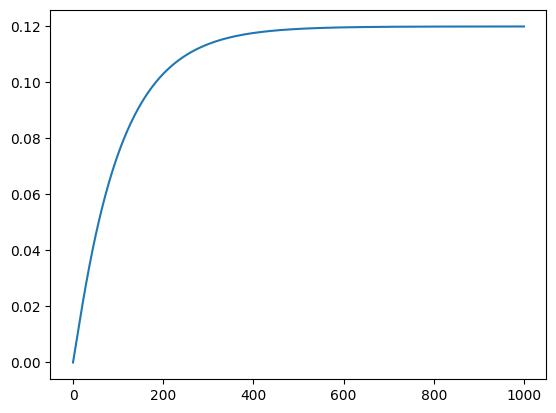

In [20]:
ucenter = u[int(L / h / 2) + 1, :]
print(ucenter)
plt.plot(ucenter)

#### **(3e) (1 punto) [P+T]**

Mantenendo gli stessi parametri di discretizzazione, ora risolvere il problema con il metodo di Eulero Esplicito e rappresentare il risultato ottenuto. Commentare il risultato ottenuto alla luce della **teoria** e proporre una strategia migliorativa.

#### **Soluzione**

Un esempio di soluzione è data dal seguente codice.

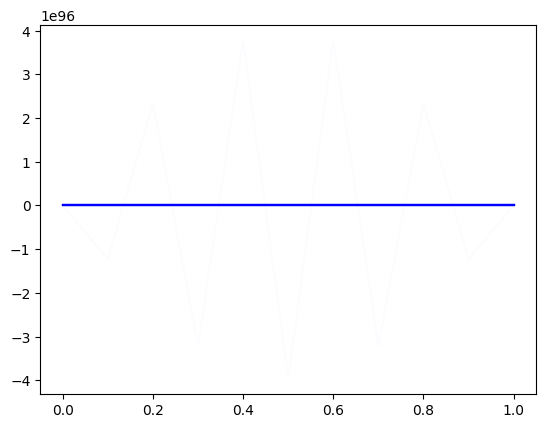

In [13]:
theta = 0
# risoluzione equazione del calore
V, u, t = heatSolve(D, f, u0, L, h, T, dt, theta)

# soluzione approssimata
xtplot(V, u, t, "fade")
plt.show()

La soluzione è instabile perché il passo temporale scelto è troppo lungo, infatti dovremmo soddisfare $\Delta t<\frac{2}{\max|\lambda(M^{-1}A)|}$. Proviamo semplicemente a utilizzare un passo temporale molto più corto:

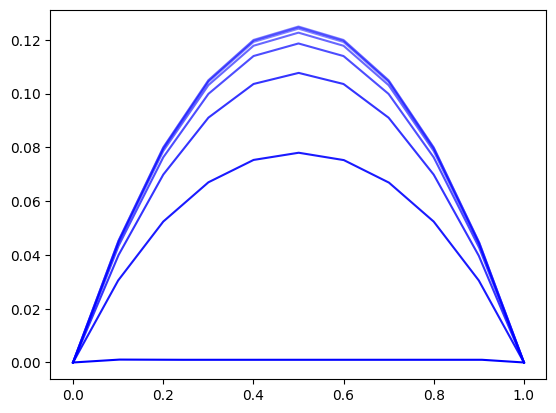

In [15]:
# risoluzione equazione del calore
V, u, t = heatSolve(D, f, u0, L, h, T, dt / 10, theta)

# soluzione approssimata
xtplot(V, u, t, "fade")
plt.show()

#### **(3f) (1 punto extra) [T]**

Calcolare analiticamente la soluzione stazionaria dell'equazione.


#### **Soluzione**

Dovendo calcolare la soluzione stazionaria allora dobbiamo trovare $u$ tale che risolve il seguente problema
\begin{gather*}
    \begin{cases}
        -   u^{\prime\prime}(x) = 1 & \text{in } \Omega          \\
        u(0) = 0                            \\
        u(1) = 0                         
    \end{cases}
\end{gather*}
Una funzione la cui derivata seconda risulta costante è la funzione quadratica del tipo
$$
    u(x) = \alpha x^2 + \beta x + \gamma \quad \Rightarrow \quad u^\prime(x) = 2 \alpha x + \beta
    \quad \Rightarrow \quad u^{\prime\prime}(x) = 2 \alpha
$$
e quindi $\alpha = -0.5$, per calcolare $\beta$ e $\gamma$ imponiamo le condizioni al bordo
$$
u(0) = \gamma = 0 \quad  \text{e} \quad u(1) = \alpha + \beta+ \gamma = 0 
$$
ottenendo quindi che $\beta = 0.5$ e $\gamma = 0$. La soluzione esatta quindi risulta
$$
    u(x) = -\frac{1}{2} x^2 + \frac{1}{2}x = \frac{1}{2} x(1-x)
$$